# Exercise 4b

Deadline 08.01.2026

Anna Bütfering

Lea Neumann

Juan Provencio



In [75]:
# Torch
import numpy as np 
print("Numpy version:", np.__version__)
import torch 
from torch.nn import functional as F
from torch import nn, optim
from torch import sqrt, exp
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921',
                                                '#8D230F', '#1B998B'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'
# Define textbox style for plots
textbox_style = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')

Numpy version: 1.26.4


## Validation

Since we didn't finish task 3 in the previous exercise, we will do so now but with the help of specialized libraries. The goal is to program a conditional invertible network (cINN) to predict the full posterior $p(Y|x)$ with the help of a summary network $h(x)$ to reduce the dimensionality of the 200-dimensional vector. As a basis for the summary network, we will use our best model for $\Phi(x)$ from exercise 4a and modify it accordingly by dropping the last layer.

Then, we drop the training method from the network class, as it will now be trained jointly with the cINN with a RealNVP

In [138]:
T = 100
N = 1000
R_0 = 0

# prior and simulation interfaces 
class Prior: 
    def __init__(self, prior_fn, labels): 
        self.prior_fn = prior_fn 
        self.labels = labels 
        self.mean = None 
        self.std = None 
        self.__set_stats__() 
     
    def __call__(self, n_samples, **kwargs): 
        return self.prior_fn(n_samples, **kwargs) 
     
    def get_labels(self): 
        return self.labels 
     
    def __set_stats__(self): 
        samples = self.prior_fn(10000) 
        self.mean = np.mean(samples, axis=0) 
        self.std = np.std(samples, axis=0) 
    
    def get_stats(self): 
        return self.mean, self.std
    
class Simulator: 
    def __init__(self, simulator_fn, prior): 
        self.simulator_fn = simulator_fn 
        self.labels = ['dS', 'dR'] 
        self.C = ['S', 'I', 'R'] 
        self.mean = None 
        self.std = None 
        self.__set_stats__(prior(10000)) 
     
    def __call__(self, prior_samples, return_C=False): 
        X, C = np.zeros((prior_samples.shape[0], T, len(self.labels))), np.zeros((prior_samples.shape[0], T, len(self.C))) 
        for i, p in enumerate(prior_samples): 
            X[i,...], C[i,...] = self.simulator_fn(*p) 
        if return_C: 
            return C 
        else: 
            return X 
     
    def get_labels(self): 
        return self.labels 
     
    def __set_stats__(self, prior_samples): 
        sim_samples = np.zeros((prior_samples.shape[0], T, len(self.labels))) 
        for i, p in enumerate(prior_samples): 
            sim_samples[i] = self.simulator_fn(*p)[0] 
        self.mean = np.mean(sim_samples, axis=0) 
        self.std = np.std(sim_samples, axis=0)     
     
    def get_stats(self): 
        return self.mean, self.std

def generate_data(n_data_points, prior, simulator): 
    prior_mean, prior_std = prior.get_stats() 
    sim_mean, sim_std = simulator.get_stats() 
 
    prior_samples = prior(n_data_points) 
    norm_prior_samples = (prior_samples - prior_mean) / prior_std 
 
    sir_observations = simulator(prior_samples) 
    # convert to channels first 
    norm_sir_observations = (sir_observations - sim_mean) / sim_std 
    norm_sir_observations = np.nan_to_num(norm_sir_observations) 
    norm_sir_observations = np.moveaxis(norm_sir_observations, -1, 1) 
 
    return norm_prior_samples, norm_sir_observations

def _deriv(input, N, lam, mu): 
    S, I, _ = input 
    dS = -lam * S * I / N 
    dI = lam * S * I / N - mu * I 
    dR = mu * I 
    return dS, dI, dR 
 
def simulate_sir_sample(lam, mu, I_0, T=T, N=N, R_0=R_0): 
    S, I, R = np.zeros(T), np.zeros(T), np.zeros(T) 
    dS, dI, dR = np.zeros(T), np.zeros(T), np.zeros(T) 
 
    # Initial conditions 
    S[0], I[0], R[0] = N - I_0 - R_0, I_0, R_0 
 
    for i in range(1, T): 
        dS[i], dI[i], dR[i] = _deriv((S[i-1], I[i-1], R[i-1]), N, lam, mu) 
        S[i], I[i], R[i] = S[i-1] + dS[i], I[i-1] + dI[i], R[i-1] + dR[i] 
 
    X = np.stack((dS, dR), axis=-1) 
    C = np.stack((S, I, R), axis=-1) 
 
    return X, C

# Summary network:
class SummaryNN(nn.Module):
    def __init__(self, layers_sizes=[128, 128], last_layer = True):
        super().__init__()

        self.losses = []
        # Ordinary Feed Forward Network Architecture with ReLU activations
        # Keep in mind, input is of size 100
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(200, layers_sizes[0]))  # Input layer: 100 days * 2 features (delta S, delta R)
        # Hidden variables with variable sizes
        for i in range(len(layers_sizes) - 1):
            self.layers.append(nn.Linear(layers_sizes[i], layers_sizes[i+1]))
        if last_layer:
            self.output_layer = nn.Linear(layers_sizes[-1], 3)  # Output: lam, mu, I_0

    def forward(self, X):
        for layer in self.layers:
            X = F.relu(layer(X))
        if hasattr(self, 'output_layer'):
            X = self.output_layer(X)
        return X  
    
# Generate training data
def generate_training_data(n_samples, T):
    X_train = []
    y_train = []
    for _ in range(n_samples):
        # Sample from prior
        lam = np.random.uniform(0.1, 0.4)
        mu = np.random.uniform(0.05, 0.25)
        I_0 = np.random.uniform(0.05, 0.4)
        # Simulate SIR
        x, c = simulate_sir_sample(lam, mu, I_0, T)
        X_train.append(np.array(x).flatten())
        y_train.append([lam, mu, I_0])
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    return X_train, y_train

In [139]:
# Prepare data
X_train, y_train = generate_training_data(n_samples=1000, T=100)
X_val, y_val = generate_training_data(n_samples=250, T=100)

We use the FrEIA (Framework for Easily Invertible Architectures) in python to create our cINN:

In [140]:
import FrEIA.framework as ff
import FrEIA.modules as fm

def build_cinn(params_dim = 3, summary_dim = 32, dropout_rate = 0.0):
    # Define DenseNet: 
    # internal, fully connected, not invertible network for coupling layers
    def dense_net(dims_in, dims_out):
        if dropout_rate > 0.0:
            return nn.Sequential(nn.Linear(dims_in, 512),
                                 nn.ReLU(),
                                 nn.Dropout(dropout_rate),
                                 nn.Linear(512, dims_out))
        else: 
            return nn.Sequential(nn.Linear(dims_in, 512),
                                nn.ReLU(),
                                nn.Linear(512, dims_out))
    
    # Define cINN architecture
    inn = ff.SequenceINN(params_dim)
    for k in range(8): # 8 coupling layers like in the example solution
        inn.append(fm.AllInOneBlock, 
                   cond=0,
                   subnet_constructor=dense_net,
                   cond_shape=(summary_dim,),
                   permute_soft=True)
        
    return inn

# Loss functions (copied from sample solution)
def nll_loss_gaussian(z, log_det_J): 
    """ 
    Computes the Kullback-Leibler divergence between the true and approximate 
    posterior assuming a Gaussian latent space as a source distribution. 
    """ 
    loss = torch.mean(0.5 * torch.square(torch.norm(z, dim=-1)) - log_det_J) 
    return loss

# MMD loss (copied from sample solution)
def kernel(X, Y, sigma, reduce_mean=True): 
    mat = X[:,None]-Y 
    mat = mat**2 
    mat = -mat/((float(sigma)**2) * 2) 
    mat = torch.exp(mat) 
    if reduce_mean: 
        mat = torch.mean(mat) 
    return mat

def compute_mmd(X, Y, sigma=[0.1, 0.5, 1, 2, 5]): 
    if isinstance(sigma, (int, float)): 
        return torch.sqrt(torch.abs(kernel(X, X, sigma) + kernel(Y, Y, sigma) - 2. * kernel(X, Y, sigma
))) 
    elif isinstance(sigma, list): 
        total_mmd = 0 
        for kernel_size in sigma: 
            total_mmd += compute_mmd(X, Y, kernel_size) 
        return total_mmd

In [156]:
# Setup
dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train), 
                                         batch_size=256, 
                                         shuffle=True)
dataloader_val = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val),
                                             batch_size=256,
                                             shuffle=False)
summary_net = SummaryNN(layers_sizes=[128, 128], last_layer=False, )
inn = build_cinn(params_dim=3, summary_dim=128, dropout_rate=0.0)
optimizer = optim.Adam(list(summary_net.parameters()) + list(inn.parameters()), lr=0.0001)

# Training loop
def training_loop(mmd_factor = 0.0):
    loss_history = {"train": [], "validation": []}
    n_epochs = 2000
    # Training
    for epoch in tqdm(range(n_epochs)):
        epoch_loss = 0
        # Switch to training mode
        summary_net.train()
        inn.train()

        for X_batch, y_batch in dataloader:

            optimizer.zero_grad()
            # Get summary net output
            summary = summary_net(X_batch)
            # Forward pass through cINN
            z, log_jac_det = inn(y_batch, c=[summary])
            prior_samples = torch.randn_like(z)
            # Compute NLL Gaussian loss
            loss = nll_loss_gaussian(z, log_jac_det)
            # Compute MMD loss (if mmd_factor > 0)
            if mmd_factor > 0:
                loss += compute_mmd(z, prior_samples) * mmd_factor

            # Append to list
            loss_history["train"].append(loss.item())
            # Backpropagation
            loss.backward()
            # Clip gradients due to exploding gradients
            nn.utils.clip_grad_norm_(summary_net.parameters(), max_norm=1)
            optimizer.step()

        # Include validation loss to detect overfitting (Toggle to evaluation mode)
        summary_net.eval()
        inn.eval()
        with torch.no_grad():
            for X_val_batch, y_val_batch in dataloader_val:
                summary_val = summary_net(X_val_batch)
                z_val, log_jac_det_val = inn(y_val_batch, c=[summary_val])
                prior_samples_val = torch.randn_like(z_val)
                val_loss = nll_loss_gaussian(z_val, log_jac_det_val)
                if mmd_factor > 0:
                    val_loss += compute_mmd(z_val, prior_samples_val) * mmd_factor
                loss_history["validation"].append(val_loss)

    
    return loss_history, summary_net, inn

loss_history, summary_net, inn = training_loop()

100%|██████████| 2000/2000 [04:51<00:00,  6.86it/s]


In [157]:
print(summary_net)

SummaryNN(
  (layers): ModuleList(
    (0): Linear(in_features=200, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
  )
)


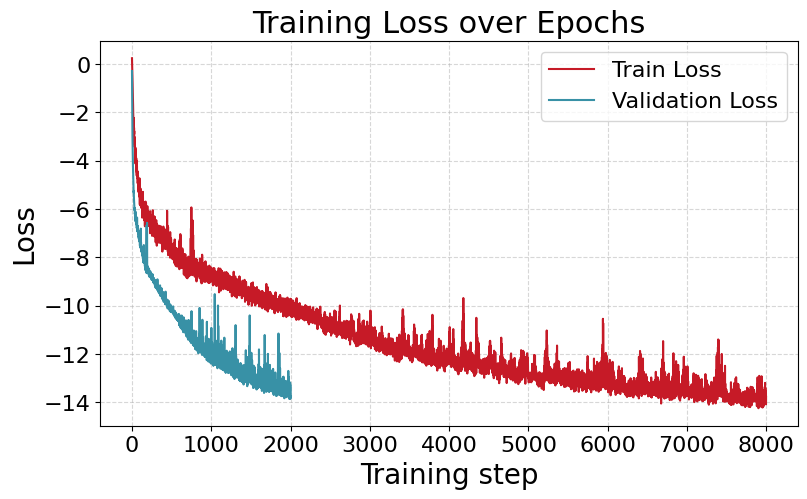

In [158]:
# Plot training loss
plt.figure(figsize=(9,5))
plt.plot(loss_history["train"], label = "Train Loss")
plt.plot(loss_history["validation"], label = "Validation Loss")
#plt.yscale('log')
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

We run the trained model on some test data generated by the simulation

In [159]:
# Define prior and simulator
prior = Prior(prior_fn=lambda n: np.column_stack((
    np.random.uniform(0.1, 0.4, size=n),  # lam
    np.random.uniform(0.05, 0.25, size=n),  # mu
    np.random.uniform(0.05, 0.4, size=n)  # I_0
)), labels=['lam', 'mu', 'I_0'])

simulator = Simulator(simulator_fn=simulate_sir_sample, prior=prior)

# Get test data function (adapted from sample solution)
def get_test_data(summary, inn, data_config, noise=0.0): 
    # Generate test data
    test_prior, test_sim = generate_data(data_config['n_test'], data_config['prior'], data_config['simulator']) 
    
    # Add noise to prior if specified
    test_prior = test_prior + np.random.normal(0, noise, size=test_prior.shape) 
    
    # Tensor conversion
    test_sim_tensor = torch.tensor(test_sim, dtype=torch.float32)
    test_prior_tensor = torch.tensor(test_prior, dtype=torch.float32)
    
    # Reshape from (batch, 2, 100) to (batch, 200) to match SummaryNN input 
    test_sim_tensor = test_sim_tensor.reshape(test_sim_tensor.shape[0], -1)
 
    summary.eval() 
    inn.eval() 
    
    with torch.no_grad():
        # Extract summary features h(x)
        conditions = summary(test_sim_tensor) 
        
        # Get latents (z) for ground truth parameters
        latents, _ = inn(test_prior_tensor, c=[conditions]) 
        
        # Sample from Posterior: draw z ~ N(0, I) and pass through inverse cINN
        n_samples = data_config['n_posterior_samples']
        n_test = data_config['n_test']
        param_dim = test_prior.shape[-1]
        
        post_samples = np.zeros((n_test, n_samples, param_dim)) 
        
        for i in range(n_samples): 
            z_rand = torch.randn_like(latents)
            samples, _ = inn(z_rand, c=[conditions], rev=True)
            post_samples[:, i, :] = samples.detach().cpu().numpy()
 
    # Unnormalize everything back to original parameter scales 
    prior_mean, prior_std = data_config['prior'].get_stats() 
    unnorm_prior = test_prior * prior_std + prior_mean 
    unnorm_post_samples = post_samples * prior_std + prior_mean 
    
    # Get raw SIR trajectories for visualization if needed
    sim_individuals = data_config['simulator'](unnorm_prior, return_C=True) 
 
    return {
        'norm_prior': test_prior, 
        'norm_X': test_sim, 
        'norm_posterior': post_samples, 
        'prior': unnorm_prior, 
        'C': sim_individuals, 
        'posterior': unnorm_post_samples, 
        'z': latents.cpu().numpy()
    }

In [160]:
test_data = get_test_data(summary_net, inn, 
                          data_config={'n_test': 100, 'n_posterior_samples': 1000, 'prior': prior, 'simulator': simulator}, 
                          noise=0.0)


/var/folders/dr/34chm7gn07vdb_w184vptt640000gn/T/ipykernel_51006/3132840662.py:68: RuntimeWarning: invalid value encountered in divide
  norm_sir_observations = (sir_observations - sim_mean) / sim_std


In [161]:
def plot_recovery_distribution(prior_samples, 
                               posterior_samples, 
                               labels=None, 
                               agg_func=np.median): 
    # Calculate the mean and 90% confidence intervals of the posterior samples 
    estimates = agg_func(posterior_samples, axis=1) 
    percentile_5 = np.percentile(posterior_samples, 5, axis=1) 
    percentile_95 = np.percentile(posterior_samples, 95, axis=1) 
    n_prior_params = prior_samples.shape[1] 
    if labels is None: 
        labels = [f'Parameter {i+1}' for i in range(n_prior_params)] 
 
    fig, axes = plt.subplots(1, n_prior_params, figsize=(5 * n_prior_params, 5)) 
    if n_prior_params == 1: 
        axes = [axes]  # Ensure axes is iterable for a single parameter 
 
    for i in range(n_prior_params): 
        ax = axes[i] if n_prior_params > 1 else axes 
        # Error bars represent the 90% CI 
        yerr = [estimates[:, i] - percentile_5[:, i], percentile_95[:, i] - estimates[:, i]] 
        ax.errorbar(prior_samples[:, i], estimates[:, i], yerr=yerr, fmt='o', alpha=0.5) 
        ax.plot([prior_samples[:,i].min(), prior_samples[:,i].max()],  
            [prior_samples[:,i].min(), prior_samples[:,i].max()],  
            '--', color='black', label='Ideal Prediction') 
        r2 = r2_score(prior_samples[:,i], estimates[:,i]) 
        ax.text(0.05, 0.95, f'R2: {r2:.2f}', transform=ax.transAxes, fontsize=12,  
                    verticalalignment='top') 
        ax.set_title(f'{labels[i]}') 
        ax.set_xlabel('True') 
        ax.set_ylabel('Predicted') 
     
    return fig 



[[0.22654231 0.24218721 0.07962505]
 [0.13202215 0.16276661 0.28834206]
 [0.23030983 0.11242267 0.27644713]
 [0.12029646 0.06487053 0.34502051]
 [0.27545755 0.15469951 0.33008861]]
[[[ 0.80976873  0.05523473  0.29820882]
  [ 0.75830419  0.05736418  0.29752386]
  [ 1.2174541   0.01497492  0.32358359]
  ...
  [ 0.85621225  0.04909694  0.30206169]
  [ 0.8568795   0.04804857  0.30232306]
  [ 1.09236013  0.02892999  0.31459939]]

 [[ 0.72370492  0.06889822  0.29008975]
  [ 0.60803561  0.0855212   0.28263134]
  [ 0.65117234  0.0797353   0.28472294]
  ...
  [ 0.77961635  0.06938789  0.28918972]
  [ 0.76456754  0.07363799  0.286778  ]
  [ 0.75798419  0.07271752  0.28767782]]

 [[ 0.28721794  0.12619554  0.24656687]
  [ 0.30149748  0.12231921  0.25348706]
  [ 0.29124543  0.12866185  0.2447681 ]
  ...
  [ 0.29152409  0.13393776  0.2388743 ]
  [ 0.29840639  0.12484583  0.25037644]
  [ 0.29033686  0.12968097  0.24336502]]

 [[ 0.88603614 -1.07933202  0.73746605]
  [ 0.89886835 -1.07290994  0.73486

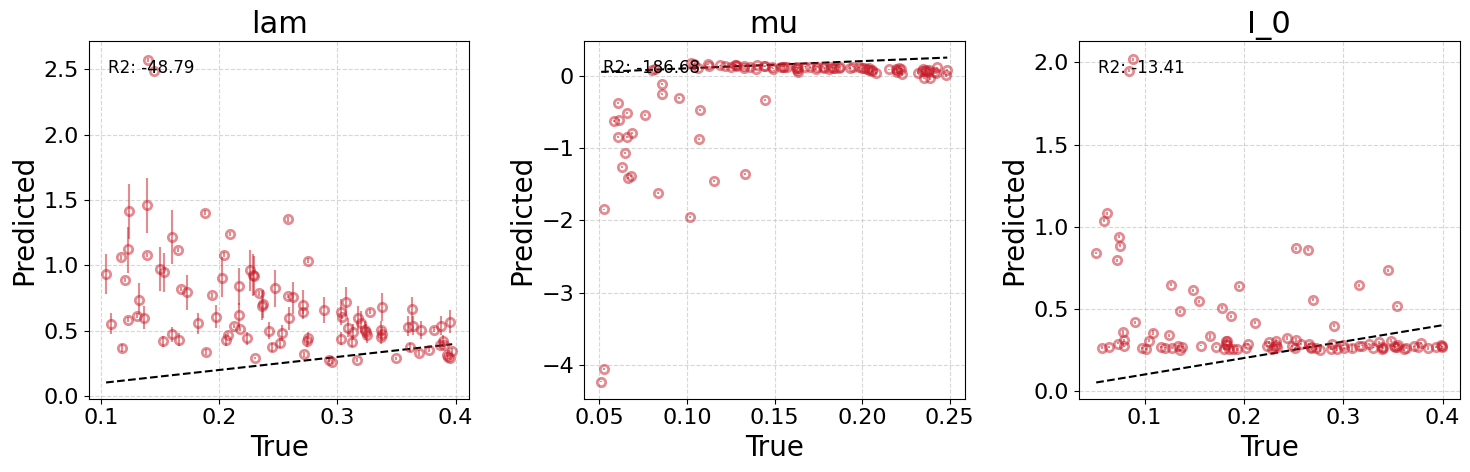

In [127]:
fig = plot_recovery_distribution(test_data['prior'][:100,:], test_data['posterior'][:100,:,:], labels=prior.get_labels())
#fig.axes[0].set_ylim(0, 1)
#fig.axes[1].set_ylim(0, 1)
#fig.axes[2].set_ylim(0, 1)
fig.tight_layout()

print(test_data['prior'][:5,:])
print(test_data['posterior'][:5,:,:])

After several attempts to get the network to work, we give up. We thought it would be worth the effort to catch up on the work from the previous exercise, but it's not. What we gather is that the network is not learning anything, and just outputting the mean value for the parameters.